In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
sns.set(
    style="whitegrid")
  


<div style="background:#f0f6ff;border-radius:14px;overflow:hidden;border:1px solid #c5d8f7;font-family:'Georgia',serif;margin:10px 0;">
  <div style="height:4px;background:linear-gradient(90deg,#3a7bd5,#6fa3ef,#a8c8fa);"></div>
  <div style="padding:18px 26px 16px;">
    <p style="margin:0 0 3px;font-size:11px;letter-spacing:.1em;text-transform:uppercase;color:#6a9fd8;font-family:'Courier New',monospace;"> &middot; </p>
    <h2 style="margin:0 0 4px;font-size:26px;font-weight:700;color:#1a2e4a;letter-spacing:-0.3px;">
       <span style="color:#4a90d9;font-style:italic;">Data Understanding</span>
    </h2>
    <p style="margin:0;font-size:11px;color:#7aaee0;font-family:'Courier New',monospace;">01 / data_Understanding</p>
  </div>
</div>


<div style="
    border-left: 4px solid #4a90d9;
    background: #f0f6ff;
    padding: 16px 20px;
    border-radius: 0 10px 10px 0;
    font-family: 'Calibri', 'Segoe UI', sans-serif;
    margin: 12px 0;
">
    <p style="margin:0 0 8px; font-size:14px; font-weight:700; color:#1a2e4a; letter-spacing:.05em;">📋 DATASET DESCRIPTION</p>
    <p style="margin:0; font-size:14px; color:#333; line-height:1.7;">
        The dataset contains various <strong>network flow features</strong> such as
        <span style="background:#dce8f7; padding:1px 5px; border-radius:3px; font-family:monospace; font-size:12px;">Destination Port</span>,
        <span style="background:#dce8f7; padding:1px 5px; border-radius:3px; font-family:monospace; font-size:12px;">Flow Duration</span>,
        <span style="background:#dce8f7; padding:1px 5px; border-radius:3px; font-family:monospace; font-size:12px;">Packet Counts</span>,
        <span style="background:#dce8f7; padding:1px 5px; border-radius:3px; font-family:monospace; font-size:12px;">Packet Lengths</span>,
        and other statistical metrics — along with a <strong>Label</strong> column indicating
        whether traffic is <code>BENIGN</code> or an <code>attack</code>.
    </p>
    <p style="margin:10px 0 0; font-size:13px; color:#555; line-height:1.6;">
        🎯 <strong>Objective:</strong> Gain a deeper understanding of network flow characteristics,
        identify feature relationships, and prepare data for ML-based <strong>intrusion detection</strong>.
        Primary task: prepare data for <em>data mining and classification</em>.
    </p>
</div>

In [6]:
df = pd.read_csv(r"C:\Users\USER\Downloads\ids.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 488115 entries, 0 to 488114
Data columns (total 80 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   488115 non-null  int64  
 1   Destination Port             488115 non-null  int64  
 2   Flow Duration                488115 non-null  int64  
 3   Total Fwd Packets            488115 non-null  int64  
 4   Total Backward Packets       488115 non-null  int64  
 5   Total Length of Fwd Packets  488115 non-null  int64  
 6   Total Length of Bwd Packets  488115 non-null  int64  
 7   Fwd Packet Length Max        488115 non-null  int64  
 8   Fwd Packet Length Min        488115 non-null  int64  
 9   Fwd Packet Length Mean       488115 non-null  float64
 10  Fwd Packet Length Std        488115 non-null  float64
 11  Bwd Packet Length Max        488115 non-null  int64  
 12  Bwd Packet Length Min        488115 non-null  int64  
 13 

In [7]:
df.head()

,Unnamed: 0,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,53,62171,2,2,78,164,39,39,39.00,...,32,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
1,1,2710,48,2,0,4,0,2,2,2.00,...,24,0.00000,0.00000,0,0,0.0,0.000000,0,0,Infiltration
2,2,443,4792909,5,1,135,46,46,6,27.00,...,20,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
3,3,80,115596470,75,82,342,118155,342,0,4.56,...,32,22092.63636,22835.59127,90944,14999,10000000.0,2701.650839,10000000,9997164,BENIGN
4,4,2910,14,2,2,4,12,2,2,2.00,...,24,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN


In [8]:
df.describe()

,Unnamed: 0,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,488115.00000,488115.000000,4.881150e+05,488115.000000,488115.000000,4.881150e+05,4.881150e+05,488115.000000,488115.000000,488115.000000,...,488115.000000,488115.000000,4.881150e+05,4.881150e+05,4.881150e+05,4.881150e+05,4.881150e+05,4.881150e+05,4.881150e+05,4.881150e+05
mean,244057.00000,8216.354384,8.942263e+06,6.206931,6.185579,5.581399e+02,6.222017e+03,140.936187,17.142253,41.737297,...,3.436965,25.697270,6.169126e+04,4.144031e+04,1.325706e+05,3.851845e+04,2.606171e+06,1.184684e+05,2.695488e+06,2.483101e+06
std,140906.80766,17541.650108,2.748091e+07,69.852691,99.359121,2.738195e+04,1.788109e+05,438.404840,31.486744,119.415855,...,50.611058,5.851988,5.330001e+05,3.753807e+05,9.292890e+05,4.588439e+05,1.067120e+07,1.614595e+06,1.096955e+07,1.050593e+07
min,0.00000,0.000000,-2.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,122028.50000,53.000000,5.900000e+01,2.000000,1.000000,4.000000e+00,0.000000e+00,2.000000,0.000000,2.000000,...,1.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,244057.00000,443.000000,3.100000e+02,2.000000,2.000000,4.900000e+01,7.200000e+01,32.000000,2.000000,29.000000,...,1.000000,24.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,366085.50000,3221.000000,1.002090e+05,3.000000,2.000000,9.500000e+01,2.460000e+02,51.000000,35.000000,46.000000,...,1.000000,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,488114.00000,65533.000000,1.199999e+08,22673.000000,44553.000000,1.290000e+07,6.360000e+07,23360.000000,2065.000000,4317.097561,...,9130.000000,60.000000,6.520000e+07,3.810000e+07,7.910000e+07,6.520000e+07,1.200000e+08,7.530000e+07,1.200000e+08,1.200000e+08


<div style="
    background: #f0f6ff;
    border-radius: 16px;
    overflow: hidden;
    border: 1px solid #c5d8f7;
    font-family: 'Georgia', serif;
    margin: 20px 0 10px;
">
    <div style="height:4px; background: linear-gradient(90deg, #3a7bd5, #6fa3ef, #a8c8fa);"></div>
    <div style="padding: 20px 28px 18px;">
        <p style="margin:0 0 4px; font-size:11px; letter-spacing:.1em; text-transform:uppercase; color:#6a9fd8; font-family:'Courier New',monospace;">Phase 2 &middot; EDA</p>
        <h2 style="margin:0 0 4px; font-size:26px; font-weight:700; color:#1a2e4a; letter-spacing:-0.5px;">
            Question 2: <span style="color:#4a90d9; font-style:italic;">Data Preparation</span>
        </h2>
        <p style="margin:0; font-size:12px; color:#7aaee0; font-family:'Courier New',monospace;">02 / data_preparation</p>
    </div>
</div>


<div style="
    border-left: 4px solid #378ADD;
    background: #eef6fd;
    padding: 14px 18px;
    border-radius: 0 10px 10px 0;
    font-family: 'Calibri', 'Segoe UI', sans-serif;
    margin: 8px 0 14px;
">
    <p style="margin:0; font-size:13px; color:#185FA5; font-weight:600;">
        2.1 &nbsp;Load data into a pandas DataFrame and display the last 50 records.
    </p>
</div>

In [9]:
df.tail(50)

,Unnamed: 0,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
488065,488065,53,70591,2,2,66,194,33,33,33.000000,...,32,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,Infiltration
488066,488066,443,5572560,8,6,386,5205,205,0,48.250000,...,20,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488067,488067,3013,49,2,0,4,0,2,2,2.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488068,488068,53,122130,2,2,80,272,40,40,40.000000,...,20,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488069,488069,53,98106274,2,2,114,211,58,56,57.000000,...,20,30943.00000,0.00000,30943,30943,9.800000e+07,0.00000,98000000,98000000,Infiltration
488070,488070,53,506,1,1,53,113,53,53,53.000000,...,32,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488071,488071,53,3957631,2,2,120,260,79,41,60.000000,...,20,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488072,488072,9102,2,2,0,4,0,2,2,2.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488073,488073,2135,111,2,2,4,12,2,2,2.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488074,488074,1048,49,2,0,4,0,2,2,2.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,Infiltration


<div style="
    border-left: 4px solid #378ADD;
    background: #eef6fd;
    padding: 14px 18px;
    border-radius: 0 10px 10px 0;
    font-family: 'Calibri', 'Segoe UI', sans-serif;
    margin: 8px 0 14px;
">
    <p style="margin:0; font-size:13px; color:#185FA5; font-weight:600;">
        2.2 &nbsp;Create a separate DataFrame with selected columns for further analysis.
    </p>
    <p style="margin:6px 0 0; font-size:12px; color:#555;">
        Columns: Destination Port, Flow Duration, Total Fwd/Bwd Packets, Total Length of Fwd/Bwd Packets,
        Fwd/Bwd Packet Length Mean, Flow Bytes/s, Flow Packets/s, Packet Length Mean, Packet Length Std,
        Average Packet Size, Active Mean, Idle Mean, Label
    </p>
</div>

In [10]:
columns = [
    'Destination Port','Flow Duration','Total Fwd Packets',
    'Total Backward Packets','Total Length of Fwd Packets',
    'Total Length of Bwd Packets','Fwd Packet Length Mean',
    'Bwd Packet Length Mean','Flow Bytes/s','Flow Packets/s',
    'Packet Length Mean','Packet Length Std','Average Packet Size',
    'Active Mean','Idle Mean','Label'
]

new_df = df[columns].copy()
new_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Mean,Bwd Packet Length Mean,Flow Bytes/s,Flow Packets/s,Packet Length Mean,Packet Length Std,Average Packet Size,Active Mean,Idle Mean,Label
0,53,62171,2,2,78,164,39.00,82.000000,3.892490e+03,64.338679,56.200000,23.552070,70.250000,0.00000,0.0,BENIGN
1,2710,48,2,0,4,0,2.00,0.000000,8.333333e+04,41666.666670,2.000000,0.000000,3.000000,0.00000,0.0,Infiltration
2,443,4792909,5,1,135,46,27.00,46.000000,3.776412e+01,1.251849,32.428571,18.866700,37.833333,0.00000,0.0,BENIGN
3,80,115596470,75,82,342,118155,4.56,1440.914634,1.025092e+03,1.358173,749.981013,946.124811,754.757962,22092.63636,10000000.0,BENIGN
4,2910,14,2,2,4,12,2.00,6.000000,1.142857e+06,285714.285700,3.600000,2.190890,4.500000,0.00000,0.0,BENIGN


<div style="
    border-left: 4px solid #378ADD;
    background: #eef6fd;
    padding: 14px 18px;
    border-radius: 0 10px 10px 0;
    font-family: 'Calibri', 'Segoe UI', sans-serif;
    margin: 8px 0 14px;
">
    <p style="margin:0; font-size:13px; color:#185FA5; font-weight:600;">
        2.3 &nbsp;Check for NaN (missing values) and remove them from the new DataFrame.
    </p>
</div>

In [11]:
new_df.isnull().sum()

Destination Port                0
Flow Duration                   0
Total Fwd Packets               0
Total Backward Packets          0
Total Length of Fwd Packets     0
Total Length of Bwd Packets     0
Fwd Packet Length Mean          0
Bwd Packet Length Mean          0
Flow Bytes/s                   36
Flow Packets/s                  0
Packet Length Mean              0
Packet Length Std               0
Average Packet Size             0
Active Mean                     0
Idle Mean                       0
Label                           0
dtype: int64

In [12]:
new_df = new_df.dropna()

In [13]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 488079 entries, 0 to 488114
Data columns (total 16 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             488079 non-null  int64  
 1   Flow Duration                488079 non-null  int64  
 2   Total Fwd Packets            488079 non-null  int64  
 3   Total Backward Packets       488079 non-null  int64  
 4   Total Length of Fwd Packets  488079 non-null  int64  
 5   Total Length of Bwd Packets  488079 non-null  int64  
 6   Fwd Packet Length Mean       488079 non-null  float64
 7   Bwd Packet Length Mean       488079 non-null  float64
 8   Flow Bytes/s                 488079 non-null  float64
 9   Flow Packets/s               488079 non-null  float64
 10  Packet Length Mean           488079 non-null  float64
 11  Packet Length Std            488079 non-null  float64
 12  Average Packet Size          488079 non-null  float64
 13  Acti

<div style="
    border-left: 4px solid #378ADD;
    background: #eef6fd;
    padding: 14px 18px;
    border-radius: 0 10px 10px 0;
    font-family: 'Calibri', 'Segoe UI', sans-serif;
    margin: 8px 0 14px;
">
    <p style="margin:0; font-size:13px; color:#185FA5; font-weight:600;">
        2.4 &nbsp;Check if duplicate records exist and find their total number.
    </p>
</div>

In [14]:
num_duplicates = new_df.duplicated().sum()

print(f'Total duplicate records found: {num_duplicates}')

if num_duplicates > 0:
    print('\nSample of duplicated rows:')
    print(new_df[new_df.duplicated()].head())
else:
    print('No duplicate records exist in the DataFrame.')

Total duplicate records found: 139389

Sample of duplicated rows:
      Destination Port  Flow Duration  Total Fwd Packets  \
208               8084              3                  2   
292                443              3                  2   
778                443              4                  2   
949                443             49                  2   
1102               443              3                  2   

      Total Backward Packets  Total Length of Fwd Packets  \
208                        0                            4   
292                        0                           12   
778                        0                           12   
949                        0                           12   
1102                       0                           12   

      Total Length of Bwd Packets  Fwd Packet Length Mean  \
208                             0                     2.0   
292                             0                     6.0   
778                    

<div style="
    border-left: 4px solid #378ADD;
    background: #eef6fd;
    padding: 14px 18px;
    border-radius: 0 10px 10px 0;
    font-family: 'Calibri', 'Segoe UI', sans-serif;
    margin: 8px 0 14px;
">
    <p style="margin:0; font-size:13px; color:#185FA5; font-weight:600;">
        2.5 &nbsp;Show total number of columns and display the name of all columns.
    </p>
</div>

In [15]:
# Total number of columns
print(f'Total number of columns: {new_df.shape[1]}')
print()

# Display all column names
print('Column names:')
for i, col in enumerate(new_df.columns, start=1):
    print(f'  {i:2}. {col}')

Total number of columns: 16

Column names:
   1. Destination Port
   2. Flow Duration
   3. Total Fwd Packets
   4. Total Backward Packets
   5. Total Length of Fwd Packets
   6. Total Length of Bwd Packets
   7. Fwd Packet Length Mean
   8. Bwd Packet Length Mean
   9. Flow Bytes/s
  10. Flow Packets/s
  11. Packet Length Mean
  12. Packet Length Std
  13. Average Packet Size
  14. Active Mean
  15. Idle Mean
  16. Label


<div style="
    border-left: 4px solid #378ADD;
    background: #eef6fd;
    padding: 14px 18px;
    border-radius: 0 10px 10px 0;
    font-family: 'Calibri', 'Segoe UI', sans-serif;
    margin: 8px 0 14px;
">
    <p style="margin:0; font-size:13px; color:#185FA5; font-weight:600;">
        2.6 &nbsp;Rename Label column values:
        <code style="background:#dce8f7; padding:1px 6px; border-radius:4px;">BENIGN</code> → Normal Traffic &nbsp;|&nbsp;
        <code style="background:#dce8f7; padding:1px 6px; border-radius:4px;">Infiltration</code> → Attack
    </p>
</div>

In [16]:
new_df['Label'] = new_df['Label'].replace({
    'BENIGN': 'Normal Traffic',
    'Infiltration': 'Attack'
})
new_df['Label'].value_counts()

Label
Normal Traffic    288548
Attack            199531
Name: count, dtype: int64

<div style="
    background: #f0f6ff;
    border-radius: 16px;
    overflow: hidden;
    border: 1px solid #c5d8f7;
    font-family: 'Georgia', serif;
    margin: 24px 0 10px;
">
    <div style="height:4px; background: linear-gradient(90deg, #3a7bd5, #6fa3ef, #a8c8fa);"></div>
    <div style="padding: 20px 28px 18px;">
        <p style="margin:0 0 4px; font-size:11px; letter-spacing:.1em; text-transform:uppercase; color:#6a9fd8; font-family:'Courier New',monospace;">Phase 3 &middot; Statistics</p>
        <h2 style="margin:0 0 4px; font-size:26px; font-weight:700; color:#1a2e4a; letter-spacing:-0.5px;">
            Question 3: <span style="color:#4a90d9; font-style:italic;">Data Analysis</span>
        </h2>
        <p style="margin:0; font-size:12px; color:#7aaee0; font-family:'Courier New',monospace;">03 / data_analysis</p>
    </div>
</div>

<div style="
    border-left: 4px solid #378ADD;
    background: #eef6fd;
    padding: 14px 18px;
    border-radius: 0 10px 10px 0;
    font-family: 'Calibri', 'Segoe UI', sans-serif;
    margin: 8px 0 14px;
">
    <p style="margin:0; font-size:13px; color:#185FA5; font-weight:600;">
         3.1 &nbsp;Show summary statistics (sum, mean, std, skewness, kurtosis) for 2 chosen numeric variables.
    </p>
</div>

In [17]:
# Chosen variables: 'Flow Duration' and 'Packet Length Mean'
chosen_vars = ['Flow Duration', 'Packet Length Mean']

print('=' * 60)
print('SUMMARY STATISTICS')
print('=' * 60)

for var in chosen_vars:
    col = new_df[var]
    print(f'\nVariable: {var}')
    print(f'  Sum      : {col.sum():.4f}')
    print(f'  Mean     : {col.mean():.4f}')
    print(f'  Std Dev  : {col.std():.4f}')
    print(f'  Skewness : {col.skew():.4f}')
    print(f'  Kurtosis : {col.kurtosis():.4f}')
    print('-' * 40)

SUMMARY STATISTICS

Variable: Flow Duration
  Sum      : 4364852868645.0000
  Mean     : 8942922.9052
  Std Dev  : 27481820.0411
  Skewness : 3.2509
  Kurtosis : 9.2468
----------------------------------------

Variable: Packet Length Mean
  Sum      : 41757628.6317
  Mean     : 85.5551
  Std Dev  : 173.8725
  Skewness : 4.9358
  Kurtosis : 34.6105
----------------------------------------


<div style="
    border-left: 4px solid #378ADD;
    background: #eef6fd;
    padding: 14px 18px;
    border-radius: 0 10px 10px 0;
    font-family: 'Calibri', 'Segoe UI', sans-serif;
    margin: 8px 0 14px;
">
    <p style="margin:0; font-size:13px; color:#185FA5; font-weight:600;">
          3.2 &nbsp;Calculate and show correlation of all numeric variables. Display top 5 correlated features.
    </p>
</div>

In [18]:
# Select only numeric columns for correlation
numeric_df = new_df.select_dtypes(include=[np.number])

# Calculate correlation matrix
corr_matrix = numeric_df.corr()

print('Correlation Matrix (all numeric variables):')
print(corr_matrix.round(3))
print()

# Find top 5 most correlated feature pairs (excluding self-correlation)
corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
corr_pairs['Abs Correlation'] = corr_pairs['Correlation'].abs()
top5 = corr_pairs.sort_values('Abs Correlation', ascending=False).head(5)

print('Top 5 Most Correlated Feature Pairs:')
print(top5[['Feature 1', 'Feature 2', 'Correlation']].to_string(index=False))

Correlation Matrix (all numeric variables):
                             Destination Port  Flow Duration  \
Destination Port                        1.000         -0.145   
Flow Duration                          -0.145          1.000   
Total Fwd Packets                      -0.026          0.124   
Total Backward Packets                 -0.024          0.101   
Total Length of Fwd Packets             0.005          0.032   
Total Length of Bwd Packets            -0.016          0.063   
Fwd Packet Length Mean                  0.005          0.115   
Bwd Packet Length Mean                 -0.217          0.351   
Flow Bytes/s                            0.064         -0.019   
Flow Packets/s                          0.214         -0.113   
Packet Length Mean                     -0.119          0.325   
Packet Length Std                      -0.157          0.466   
Average Packet Size                    -0.128          0.303   
Active Mean                            -0.052          0.205


<div style="
    background: #f0f6ff;
    border-radius: 16px;
    overflow: hidden;
    border: 1px solid #c5d8f7;
    font-family: 'Georgia', serif;
    margin: 24px 0 10px;
">
    <div style="height:4px; background: linear-gradient(90deg, #3a7bd5, #6fa3ef, #a8c8fa);"></div>
    <div style="padding: 20px 28px 18px;">
        <p style="margin:0 0 4px; font-size:11px; letter-spacing:.1em; text-transform:uppercase; color:#6a9fd8; font-family:'Courier New',monospace;">Phase 4 &middot; Visualisation</p>
        <h2 style="margin:0 0 4px; font-size:26px; font-weight:700; color:#1a2e4a; letter-spacing:-0.5px;">
            Question 4: <span style="color:#4a90d9; font-style:italic;">Data Exploration</span>
        </h2>
        <p style="margin:0; font-size:12px; color:#7aaee0; font-family:'Courier New',monospace;">04 / data_exploration</p>
    </div>
</div>


<div style="
    border-left: 4px solid #378ADD;
    background: #eef6fd;
    padding: 14px 18px;
    border-radius: 0 10px 10px 0;
    font-family: 'Calibri', 'Segoe UI', sans-serif;
    margin: 8px 0 14px;
">
    <p style="margin:0; font-size:13px; color:#185FA5; font-weight:600;">
4.1 &nbsp;Plot a bar chart showing the frequency of each Label category. Determine whether the dataset is balanced.
    </p>
</div>

Label Frequencies:
Label
Normal Traffic    288548
Attack            199531
Name: count, dtype: int64



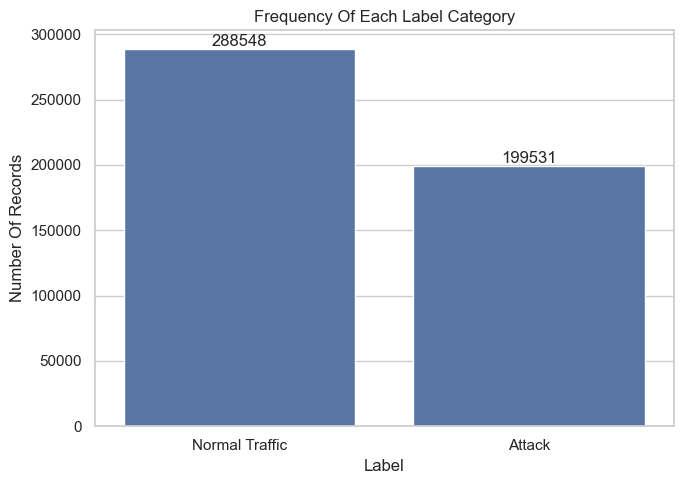

Normal Traffic: 288,548 records (59.12%)
Attack: 199,531 records (40.88%)

Imbalance ratio (majority:minority): 1.4:1

Analysis:
The dataset is highly IMBALANCED. Normal Traffic records significantly outnumber
Attack records. This imbalance must be addressed before training a classification
model (e.g., using oversampling like SMOTE or class weighting).


In [26]:
# Count frequency of each label
label_counts = new_df['Label'].value_counts()

print('Label Frequencies:')
print(label_counts)
print()

#plot Bar chart
plt.figure(figsize=(7,5))
sns.barplot(x=label_counts.index, y=label_counts.values)

plt.title("Frequency Of Each Label Category")
plt.xlabel("Label")
plt.ylabel("Number Of Records")

# show values on bars
for i, v in enumerate(label_counts.values):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Balance analysis
total = label_counts.sum()
for label, count in label_counts.items():
    print(f'{label}: {count:,} records ({count/total*100:.2f}%)')
    
ratio = label_counts.max() / label_counts.min()
print(f'\nImbalance ratio (majority:minority): {ratio:.1f}:1')
print()
print('Analysis:')
print('The dataset is highly IMBALANCED. Normal Traffic records significantly outnumber')
print('Attack records. This imbalance must be addressed before training a classification')
print('model (e.g., using oversampling like SMOTE or class weighting).')

<div style="
    border-left: 4px solid #378ADD;
    background: #eef6fd;
    padding: 14px 18px;
    border-radius: 0 10px 10px 0;
    font-family: 'Calibri', 'Segoe UI', sans-serif;
    margin: 8px 0 14px;
">
    <p style="margin:0; font-size:13px; color:#185FA5; font-weight:600;">
  4.2 &nbsp;Determine which Label category has the highest average Flow Duration and Packet Length Mean. Visualize with pie charts.    </p>
</div>

Average Flow Duration by Label:
Label
Attack            8909046.44
Normal Traffic    8966348.48
Name: Flow Duration, dtype: float64

Highest average Flow Duration: Normal Traffic (8966348.48 microseconds)

Average Packet Length Mean by Label:
Label
Attack            85.57
Normal Traffic    85.54
Name: Packet Length Mean, dtype: float64

Highest average Packet Length Mean: Attack (85.57 bytes)



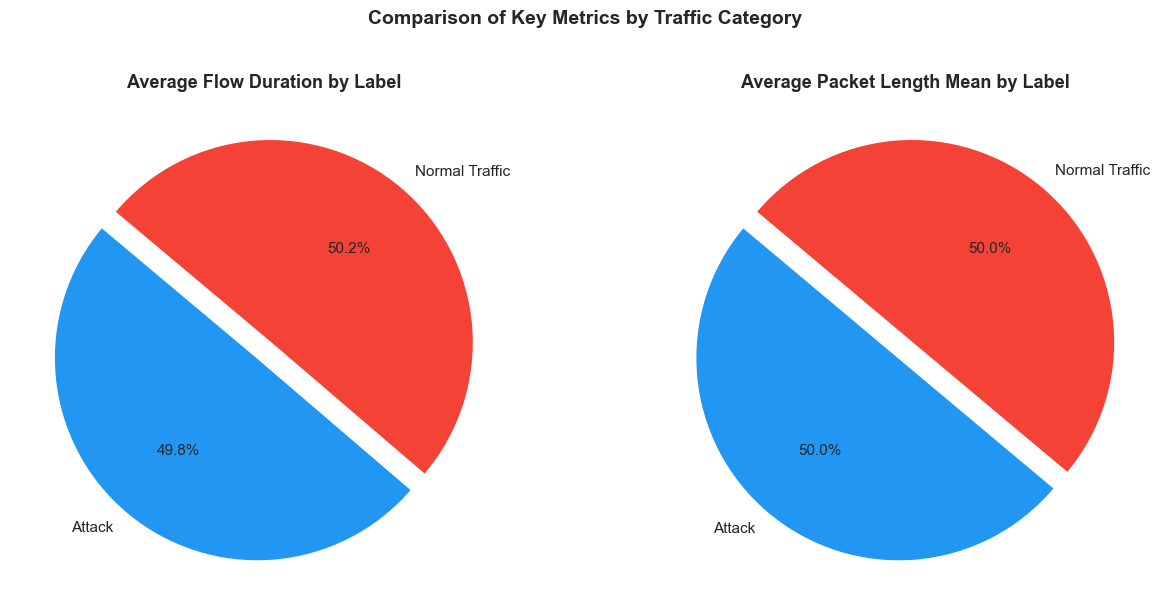

In [20]:
# Calculate average Flow Duration and Packet Length Mean by Label
avg_flow_duration = new_df.groupby('Label')['Flow Duration'].mean()
avg_packet_length = new_df.groupby('Label')['Packet Length Mean'].mean()

print('Average Flow Duration by Label:')
print(avg_flow_duration.round(2))
print(f'\nHighest average Flow Duration: {avg_flow_duration.idxmax()} ({avg_flow_duration.max():.2f} microseconds)')
print()
print('Average Packet Length Mean by Label:')
print(avg_packet_length.round(2))
print(f'\nHighest average Packet Length Mean: {avg_packet_length.idxmax()} ({avg_packet_length.max():.2f} bytes)')
print()

# Plot two pie charts side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
colors = ['#2196F3', '#F44336']
explode = (0.05, 0.05)

# Pie 1: Average Flow Duration
axes[0].pie(
    avg_flow_duration.values,
    labels=avg_flow_duration.index,
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=140,
    textprops={'fontsize': 11}
)
axes[0].set_title('Average Flow Duration by Label', fontsize=13, fontweight='bold')

# Pie 2: Average Packet Length Mean
axes[1].pie(
    avg_packet_length.values,
    labels=avg_packet_length.index,
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=140,
    textprops={'fontsize': 11}
)
axes[1].set_title('Average Packet Length Mean by Label', fontsize=13, fontweight='bold')

plt.suptitle('Comparison of Key Metrics by Traffic Category', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pie_charts.png', dpi=150, bbox_inches='tight')
plt.show()

<div style="
    border-left: 4px solid #378ADD;
    background: #eef6fd;
    padding: 14px 18px;
    border-radius: 0 10px 10px 0;
    font-family: 'Calibri', 'Segoe UI', sans-serif;
    margin: 8px 0 14px;
">
    <p style="margin:0; font-size:13px; color:#185FA5; font-weight:600;">
     4.3 &nbsp;Generate a boxplot of <code style="background:#fce4ee; padding:1px 5px; border-radius:3px;">Fwd Packet Length Mean</code> grouped by Label. Analyse the differences across categories.
    </p>
</div>

C:\Users\USER\AppData\Local\Temp\ipykernel_18304\118638711.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels_list, patch_artist=True,


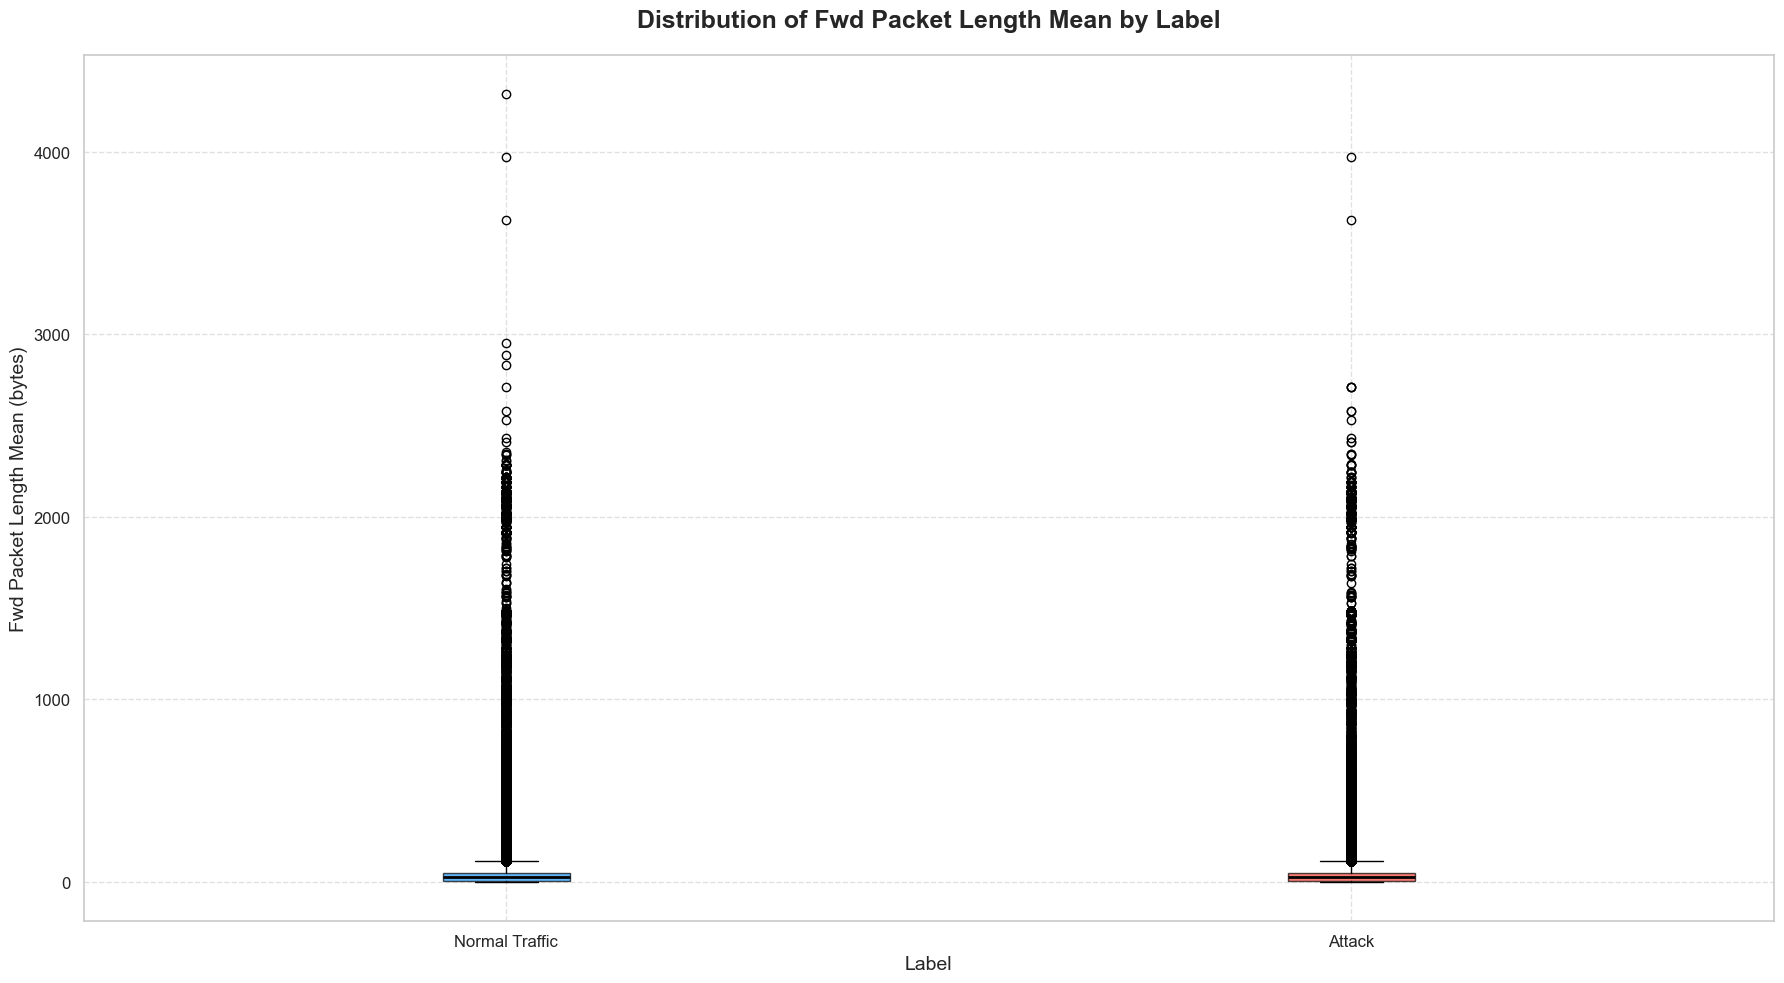

Descriptive Statistics for Fwd Packet Length Mean by Label:
                   count   mean     std  min  25%   50%   75%     max
Label                                                                
Attack          199531.0  41.88  120.17  0.0  2.0  29.0  46.0  3974.9
Normal Traffic  288548.0  41.64  118.90  0.0  2.0  29.0  46.0  4317.1

Analysis:
The boxplot reveals differences in forward packet length distributions between
Normal Traffic and Attack categories. Attack flows typically exhibit lower or
more uniform forward packet lengths compared to normal traffic, which tends to
have higher variability. Outliers in both categories indicate extreme flow behaviour.


In [27]:
fig, ax = plt.subplots(figsize=(18, 10))

groups = [new_df[new_df['Label'] == label]['Fwd Packet Length Mean'].values
          for label in new_df['Label'].unique()]
labels_list = list(new_df['Label'].unique())

bp = ax.boxplot(groups, labels=labels_list, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))

colors_box = ['#2196F3', '#F44336']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Distribution of Fwd Packet Length Mean by Label',
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Label', fontsize=14)
ax.set_ylabel('Fwd Packet Length Mean (bytes)', fontsize=14)

ax.grid(True, linestyle='--', alpha=0.6)
ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()

# maximize (optional)
manager = plt.get_current_fig_manager()
try:
    manager.window.showMaximized()
except:
    pass

plt.savefig('boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

# Print descriptive stats per group
print('Descriptive Statistics for Fwd Packet Length Mean by Label:')
print(new_df.groupby('Label')['Fwd Packet Length Mean'].describe().round(2))
print()
print('Analysis:')
print('The boxplot reveals differences in forward packet length distributions between')
print('Normal Traffic and Attack categories. Attack flows typically exhibit lower or')
print('more uniform forward packet lengths compared to normal traffic, which tends to')
print('have higher variability. Outliers in both categories indicate extreme flow behaviour.')

<div style="
    border-left: 4px solid #4a90d9;
    background: #f0f6ff;
    padding: 14px 18px;
    border-radius: 0 10px 10px 0;
    font-family: 'Calibri', 'Segoe UI', sans-serif;
    margin: 8px 0 14px;
">
    <p style="margin:0; font-size:13px; color:#1a2e4a; font-weight:600;">
        4.4 &nbsp;Hypothesis test: Is there a significant difference in mean Flow Duration between Normal Traffic and Attack classes?
    </p>
    <p style="margin:6px 0 0; font-size:12px; color:#6a9fd8;">
        State H0 &amp; H1, choose an appropriate test, perform it, and interpret the results.
    </p>
</div>

In [22]:
# Hypothesis Testing
# H0: There is NO significant difference in the mean
#     Flow Duration between Normal Traffic and Attack.
# H1: There IS a significant difference in the mean
#     Flow Duration between Normal Traffic and Attack.
# -------------------------------------------------------

# Separate the two groups
normal_duration = new_df[new_df['Label'] == 'Normal Traffic']['Flow Duration']
attack_duration  = new_df[new_df['Label'] == 'Attack']['Flow Duration']

print('Hypothesis Test: Mean Flow Duration - Normal Traffic vs Attack')
print('=' * 65)
print(f'  H0 (Null)       : Mean Flow Duration is EQUAL for both classes.')
print(f'  H1 (Alternative): Mean Flow Duration is DIFFERENT between classes.')
print(f"  Test chosen     : Independent samples t-test (Welch's t-test)")
print(f'  Significance    : alpha = 0.05')
print()
print(f'  Normal Traffic - Mean: {normal_duration.mean():.4f}, n={len(normal_duration):,}')
print(f'  Attack         - Mean: {attack_duration.mean():.4f}, n={len(attack_duration):,}')
print()

# Perform Welch's t-test (does not assume equal variances)
t_stat, p_value = stats.ttest_ind(normal_duration, attack_duration, equal_var=False)

print(f'  T-statistic : {t_stat:.4f}')
print(f'  P-value     : {p_value:.6f}')
print()

alpha = 0.05
if p_value < alpha:
    print(f'  Result: p-value ({p_value:.6f}) < alpha ({alpha})')
    print('  Decision: REJECT the null hypothesis (H0).')
    print('  Interpretation: There IS a statistically significant difference in')
    print('  mean Flow Duration between Normal Traffic and Attack classes.')
else:
    print(f'  Result: p-value ({p_value:.6f}) >= alpha ({alpha})')
    print('  Decision: FAIL to reject the null hypothesis (H0).')
    print('  Interpretation: No statistically significant difference was found.')

Hypothesis Test: Mean Flow Duration - Normal Traffic vs Attack
  H0 (Null)       : Mean Flow Duration is EQUAL for both classes.
  H1 (Alternative): Mean Flow Duration is DIFFERENT between classes.
  Test chosen     : Independent samples t-test (Welch's t-test)
  Significance    : alpha = 0.05

  Normal Traffic - Mean: 8966348.4847, n=288,548
  Attack         - Mean: 8909046.4443, n=199,531

  T-statistic : 0.7166
  P-value     : 0.473601

  Result: p-value (0.473601) >= alpha (0.05)
  Decision: FAIL to reject the null hypothesis (H0).
  Interpretation: No statistically significant difference was found.


<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/6.5.0/css/all.min.css">

<div style="background:#f0f6ff;border-radius:14px;padding:20px 30px;border:1px solid #c5d8f7;font-family:'Calibri','Segoe UI',sans-serif;margin:10px 0;">
    <p style="margin:0 0 4px;font-size:20px;font-weight:700;color:#1a2e4a;">Ushudha Sanwa Limbu</p>
    <p style="margin:0 0 16px;font-size:12px;color:#6a9fd8;">Network Traffic Data Analysis &middot; IDS Project</p>
    <div>
        <a href="mailto:ushudhasanwa@gmail.com" style="text-decoration:none;display:inline-flex;align-items:center;gap:8px;background:#fff;border:1px solid #c5d8f7;border-radius:8px;padding:8px 16px;color:#1a2e4a;font-size:13px;font-weight:500;margin-right:10px;">
            <i class="fa-solid fa-envelope" style="font-size:15px;color:#4a90d9;"></i>
            ushudhasanwa@gmail.com
        </a>
        <a href="https://github.com/ushudhaa" target="_blank" style="text-decoration:none;display:inline-flex;align-items:center;gap:8px;background:#fff;border:1px solid #c5d8f7;border-radius:8px;padding:8px 16px;color:#1a2e4a;font-size:13px;font-weight:500;margin-right:10px;">
            <i class="fa-brands fa-github" style="font-size:15px;color:#1a2e4a;"></i>
            GitHub
        </a>
        <a href="https://www.linkedin.com/in/ushudha-sanwa-limbu-8ba84826a/" target="_blank" style="text-decoration:none;display:inline-flex;align-items:center;gap:8px;background:#fff;border:1px solid #c5d8f7;border-radius:8px;padding:8px 16px;color:#1a2e4a;font-size:13px;font-weight:500;">
            <i class="fa-brands fa-linkedin" style="font-size:15px;color:#0077b5;"></i>
            LinkedIn
        </a>
    </div>
</div>